## Language Detection Model for Multilingual Text


In [14]:
# import all the required libraries for this project.

import re                      # for text cleaning (regex)
import pickle                  # for saving/loading model
import numpy as np             # for numerical operations
import pandas as pd            # for dataset handling
import unicodedata             # for unicode normalization

import matplotlib.pyplot as plt   # for plotting
import seaborn as sns             # for better visualizations

# External library for comparison
from langdetect import detect

# sklearn modules for ML pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


#remove warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [15]:
# Load CSV file (ensure encoding is correct for Urdu/Arabic text)
df = pd.read_csv("language_detection_dataset.csv", encoding="utf-8")

In [16]:
#checking the shape of the dataset
print("The shape of the dataset is:", df.shape)

The shape of the dataset is: (22000, 2)


In [17]:
# checking the missing values in the dataset
print("Missing values in the dataset:\n", df.isnull().sum())

#checking the duplicate values in the dataset
print("Duplicate values in the dataset:", df.duplicated().sum())

Missing values in the dataset:
 Text        0
language    0
dtype: int64
Duplicate values in the dataset: 141


In [18]:
# for better model training, we will remove the duplicate values from the dataset.
df = df.drop_duplicates()


In [19]:
# and now we will again check the dataset for duplicates
print("Duplicate values in the dataset after removing duplicates:", df.duplicated().sum())

Duplicate values in the dataset after removing duplicates: 0


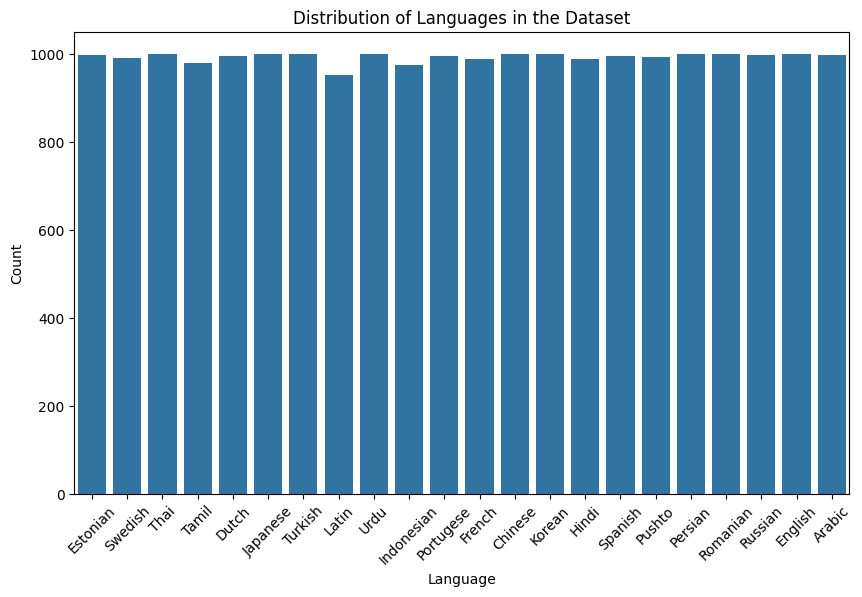

In [20]:
# visualize the distribution of languages in the dataset
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="language")
plt.title("Distribution of Languages in the Dataset")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### preprocessing and model training

In [21]:
# creating a function to preprocess the text data for better model performance.
def preprocess_text(text):
    """
    Clean text while preserving multilingual characters.
    This ensures Urdu, Arabic, Chinese, etc. are NOT destroyed.
    """

    # If input is not a string, return empty string
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [22]:
# Apply preprocessing
df['Text'] = df['Text'].apply(preprocess_text)
print("Preprocessing complete!")

Preprocessing complete!


In [23]:
# Split dataset into features and target variable
X = df["Text"]
y = df["language"]

In [24]:
# Convert language labels (text) into numeric format 
label_encoder = LabelEncoder()
df["language"] = label_encoder.fit_transform(df["language"])


In [25]:
# Save encoder for later use
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [26]:
# checking the encoded target variable to see which number is assigned to which language.
encoded_labels = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Encoded labels (Language → Numeric):\n", encoded_labels)

Encoded labels (Language → Numeric):
 {'Arabic': 0, 'Chinese': 1, 'Dutch': 2, 'English': 3, 'Estonian': 4, 'French': 5, 'Hindi': 6, 'Indonesian': 7, 'Japanese': 8, 'Korean': 9, 'Latin': 10, 'Persian': 11, 'Portugese': 12, 'Pushto': 13, 'Romanian': 14, 'Russian': 15, 'Spanish': 16, 'Swedish': 17, 'Tamil': 18, 'Thai': 19, 'Turkish': 20, 'Urdu': 21}


In [27]:
# now train test split the dataset into training and testing sets for model training and evaluation.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 17487
Test samples: 4372


In [28]:
# Define the machine learning pipeline with TF-IDF vectorizer and Logistic Regression classifier

model = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5))),
    ("classifier", LogisticRegression(max_iter=500))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9830741079597438
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       200
     Chinese       0.92      0.99      0.95       200
       Dutch       0.99      0.99      0.99       199
     English       0.82      0.99      0.90       200
    Estonian       1.00      0.98      0.99       200
      French       0.99      1.00      0.99       198
       Hindi       1.00      0.96      0.98       198
  Indonesian       1.00      0.98      0.99       195
    Japanese       1.00      1.00      1.00       200
      Korean       1.00      0.99      0.99       200
       Latin       0.97      0.95      0.96       191
     Persian       1.00      0.99      0.99       200
   Portugese       0.99      0.98      0.99       199
      Pushto       1.00      0.93      0.97       199
    Romanian       1.00      0.98      0.99       200
     Russian       0.99      0.98      0.99       200
     Spanish       0.99      0.97      0.98       19

In [29]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", round(acc, 4))
print(classification_report(y_test, y_pred))

Accuracy: 0.9831
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       200
     Chinese       0.92      0.99      0.95       200
       Dutch       0.99      0.99      0.99       199
     English       0.82      0.99      0.90       200
    Estonian       1.00      0.98      0.99       200
      French       0.99      1.00      0.99       198
       Hindi       1.00      0.96      0.98       198
  Indonesian       1.00      0.98      0.99       195
    Japanese       1.00      1.00      1.00       200
      Korean       1.00      0.99      0.99       200
       Latin       0.97      0.95      0.96       191
     Persian       1.00      0.99      0.99       200
   Portugese       0.99      0.98      0.99       199
      Pushto       1.00      0.93      0.97       199
    Romanian       1.00      0.98      0.99       200
     Russian       0.99      0.98      0.99       200
     Spanish       0.99      0.97      0.98       199
     Swedi

In [30]:
def save_model():
    with open("language_model.pkl", "wb") as f:
        pickle.dump(model, f)

def load_model():
    global model
    with open("language_model.pkl", "rb") as f:
        model = pickle.load(f)
save_model()

In [31]:
def confusion_analysis():
    cm = confusion_matrix(y_test, y_pred)
    labels = label_encoder.classes_

    plt.figure(figsize=(10,6))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\nMisclassification Summary:\n")

    for i in range(len(cm)):
        for j in range(len(cm)):
            if i != j and cm[i][j] > 0:
                print(labels[i], "→", labels[j], ":", cm[i][j])

In [32]:
def compare_with_langdetect(text):
    text = preprocess_text(text)

    try:
        ld = detect(text)
    except:
        ld = "Error"

    return {
        "Model": predict_language(text),
        "LangDetect": ld
    }

In [50]:
def predict_language(text, threshold=0.35):
    text = preprocess_text(text)

    # short text handling
    if len(text.strip()) <= 2:
        return "Unknown / Too Short Text"

    # probabilities
    proba = model.predict_proba([text])[0]
    classes = model.classes_

    # top 2 predictions
    top2 = np.argsort(proba)[-2:][::-1]

    best_idx = top2[0]
    second_idx = top2[1]

    best_conf = proba[best_idx]
    second_conf = proba[second_idx]

    # mixed language check
    if abs(best_conf - second_conf) < 0.05:
        return f"Mixed: {classes[best_idx]} / {classes[second_idx]}"

    # low confidence check
    if best_conf < threshold:
        return "Unknown / Low Confidence"

    # final prediction
    return f"{classes[best_idx]} ({round(best_conf, 2)})"

In [51]:
def predict_top2(text):
    text = preprocess_text(text)

    proba = model.predict_proba([text])[0]
    classes = model.classes_

    top2 = np.argsort(proba)[-2:][::-1]

    return [
        (label_encoder.inverse_transform([classes[i]])[0], round(proba[i], 3))
        for i in top2
    ]

In [52]:
def error_analysis(n=10):
    preds = model.predict(X_test)

    count = 0

    for text, true, pred in zip(X_test, y_test, preds):
        if true != pred:
            print("Text:", text)
            print("Actual:", label_encoder.inverse_transform([true])[0])
            print("Predicted:", label_encoder.inverse_transform([pred])[0])
            print("-")

            count += 1
            if count >= n:
                break

In [53]:
acc = model.score(X_test, y_test)

print("Final Accuracy:", round(acc, 4))

Final Accuracy: 0.9831


In [54]:
def batch_predict(input_file, output_file):
    data = pd.read_csv(input_file)

    data["Predicted_Language"] = data["Text"].fillna("").apply(predict_language)

    data.to_csv(output_file, index=False)

In [55]:
def run_cli():
    while True:
        print("\n1 Predict\n2 Top-2\n3 Compare\n4 Error\n5 Test\n6 Exit")
        choice = input("Choice: ")

        if choice == "1":
            print(predict_language(input("Text: ")))

        elif choice == "2":
            print(predict_top2(input("Text: ")))

        elif choice == "3":
            print(compare_with_langdetect(input("Text: ")))

        elif choice == "4":
            error_analysis()

        elif choice == "5":
            real_world_test()

        elif choice == "6":
            break

In [56]:
def real_world_test():
    samples = [
        "hi bro, how are you?",
        "hola amigo",
        "bonjour friend",
        "میں ٹھیک ہوں",
        "hello بھائی",
        "¿cómo estás bro?",
        "привет bro",
        "😂😂 hello",
        "12345",
        ""
    ]

    for t in samples:
        print(t, "->", predict_language(t))


# RUN THE FUNCTION
real_world_test()

hi bro, how are you? -> Unknown / Low Confidence
hola amigo -> Unknown / Low Confidence
bonjour friend -> Unknown / Low Confidence
میں ٹھیک ہوں -> Urdu (0.42)
hello بھائی -> Unknown / Low Confidence
¿cómo estás bro? -> Unknown / Low Confidence
привет bro -> Unknown / Low Confidence
😂😂 hello -> Unknown / Low Confidence
12345 -> Unknown / Low Confidence
 -> Unknown / Too Short Text
